# Module 4 — Activation: Definition & Measurement *(recap)*

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

Defining and testing an activation metric is covered in depth in the Product Analytics Case Study. This module is a short recap: the method, what the Case Study's activation notebook found (with its printed numbers and link), and one compact version of the same test on this playbook's store data.

## From the curriculum

> ## <u>Module 4 — Activation: Definition & Measurement</u> *(recap)*
>
> **Covered in:** Product Analytics Case Study,
> [`02_Activation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/02_Activation.ipynb):
> 3 signals × 3 windows, dose-response, confound and specificity checks.
>
> **Recap:** an activation definition is chosen, not discovered: candidate
> signal × window, a check for a natural break, then confound checks.
>
> **Compact recompute:** one first-week signal vs. later return on the running
> dataset.

Terms in the quote above: the **confound check** is method step 3 below, the **specificity check** is step 4, and the **running dataset** is this playbook's store data.

## Recap

**Definitions:**
- **Activation** is the first sign that a new user is getting value from the product. An **activation metric** turns it into a yes/no rule, e.g. "active on 3 or more days in the first 14 days".
- The rule has two parts: a **signal** (what the user did) and a **window** (within how long of starting).
- The **outcome** is the later result the signal should predict, e.g. passing a course, or coming back.
- **Dose-response:** the outcome improves step by step as the signal grows (e.g. each extra active day goes with a higher pass rate), rather than jumping at one point.

**The method, in four steps** (the Case Study's structure):
1. Try several signals and windows; keep the one most related to the outcome.
2. Look for a natural break (a point where the outcome jumps). If there is none, the cut-off is a choice and should be stated as one.
3. Check that the relation is not just about *who* shows up: compare within subgroups, and remove users who could not meet the signal for a reason that also decides the outcome (e.g. they left before the window ended).
4. Check that the signal predicts the outcome you actually care about (in the Case Study: staying enrolled), not just a broader one (the final grade).

### What the Case Study showed

**Product Analytics Case Study,** [`02_Activation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/02_Activation.ipynb): an online-learning platform, 32,593 course enrollments; the outcome is passing the course (Pass or Distinction). All numbers in this section are quoted from that notebook's printed outputs (it printed rates as decimals; they are shown as percentages here).

**Step 1** (section "Step 1 — which early signal, and which window?"): correlation between each signal and passing.

| window | volume (clicks) | breadth (active days) | variety (activity types) |
|---|---|---|---|
| 7 days | 0.232 | 0.325 | 0.313 |
| 14 days | 0.270 | 0.368 | 0.352 |
| 28 days | 0.297 | 0.408 | 0.367 |

Breadth (active days) was strongest in every window; 14 days was carried forward as an early-enough window.

**Step 2** (section "Step 2 — is there a natural break, or a smooth dose-response?"): the pass rate rises steadily with active days in the first 14: 12.4% at 0 days, 35.8% at 1, 49.6% at 3, 64.1% at 8, 78.5% at 14. No natural break, so "3 or more active days" was a chosen cut-off.

**Step 3** (section "Step 3 — is this real, or just which students/subjects show up?"): pass rate 60.5% activated vs. 25.8% not activated; the notebook printed the gap as 34.8 points (from unrounded rates). But 4,465 enrollments withdrew within the 14 days: they had little chance to be activated, and none of them passed (4,457 ended as "Withdrawn", 8 as "Fail"; counted directly from the Case Study's data, since its notebook doesn't print this split). Among the 28,128 that stayed at least 14 days, the printed gap is 24.5 points (62.1% vs. 37.7%). It held within every education level and age band.

**Step 4** (section "Step 4 — does activation predict retention specifically, not just final grade?"): the withdrawal gap shrinks from 27.7 points (48.0% − 20.3%) to 5.8 (24.0% − 18.2%) once early leavers are removed: most of it was the same early-leaver effect.

## Compact recompute: first-week activity vs. coming back, on this store's data

**The question:** does a new user's activity in their first week relate to whether they come back later?

**Definitions:**
- **Cohort:** one cohort, pooling all users whose first event in the data falls between 1 November and 31 December 2019 (not split by month or week). October is excluded: the data starts then, so "new" can't be measured (Module 2).
- **Day 0** = the day of the user's first event. **Signal:** number of days with any event in the **signal window: 7 days (days 0–6)**. Day 0 always counts, so the minimum is 1.
- **Outcome ("returned"):** any event in the **outcome window: 53 days (days 7–59)**. Together the two windows cover each user's first 60 days. The latest cohort users start on 31 December 2019, so their day 59 is 28 February 2020, inside the data (which ends 29 February 2020). Every user has the full 60 days.
- The signal and outcome windows don't overlap, and every user has the full 7-day signal window in the data, so no one is kept from the signal by the data ending early (the Case Study's early-leaver problem).

**Data limits, up front:**
- As in Module 2, some "new" users may be older customers who were simply inactive in October.
- Activity dips over the holidays (printed below), so users who start in late December have quiet days in their first week.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, show, BLUE, GREY

con = connect()
per_day = query(con, "SELECT event_date, COUNT(*) AS events FROM events_clean GROUP BY 1").set_index("event_date")["events"]
print(f"events per day: median = {per_day.median():,.0f}")
print(f"30-31 Dec 2019 = {per_day['2019-12-30']:,} and {per_day['2019-12-31']:,} (the lowest days in the data)")
print()

days = query(con, "SELECT user_id, event_date, events FROM daily_active")
days["event_date"] = pd.to_datetime(days["event_date"])
first_day = days.groupby("user_id")["event_date"].min().rename("day0")
days = days.join(first_day, on="user_id")
days["day"] = (days["event_date"] - days["day0"]).dt.days

cohort = first_day[(first_day >= "2019-11-01") & (first_day <= "2019-12-31")].index
c = days[days["user_id"].isin(cohort)]
users = pd.DataFrame({"active_days_week1": c[c["day"] < 7].groupby("user_id").size()})
users["returned"] = users.index.isin(c[(c["day"] >= 7) & (c["day"] < 60)]["user_id"].unique())

print(f"cohort: {len(users):,} users first seen 1 Nov - 31 Dec 2019")
print(f"returned on days 7-59: {users['returned'].sum():,} = {users['returned'].mean():.2%}")
print()
users["group"] = users["active_days_week1"].clip(upper=4).map({1: "1", 2: "2", 3: "3", 4: "4 or more"})
by_group = users.groupby("group")["returned"].agg(["size", "sum", "mean"])
show(pd.DataFrame({"active days in week 1": by_group.index,
                   "users": by_group["size"].map("{:,}".format).values,
                   "returned": by_group["sum"].map("{:,}".format).values,
                   "return rate %": (by_group["mean"] * 100).map("{:.2f}".format).values}))
rates = by_group["mean"] * 100
print("\nstep from one group to the next: " + ", ".join(f"{a} -> {b}: {rates[b] - rates[a]:+.2f} points" for a, b in zip(rates.index[:-1], rates.index[1:])))
print()
print("days 4-7 shown separately (small groups, pooled above):")
detail = users[users["active_days_week1"] >= 4].groupby("active_days_week1")["returned"].agg(["size", "mean"])
show(pd.DataFrame({"active days": detail.index, "users": detail["size"].values,
                   "return rate %": (detail["mean"] * 100).map("{:.2f}".format).values}))

events per day: median = 12,348
30-31 Dec 2019 = 6,075 and 3,492 (the lowest days in the data)



cohort: 61,557 users first seen 1 Nov - 31 Dec 2019
returned on days 7-59: 9,293 = 15.10%

active days in week 1   users  returned  return rate %
1                      53,872     6,389          11.86
2                       5,890     1,885          32.00
3                       1,180       602          51.02
4 or more                 615       417          67.80

step from one group to the next: 1 -> 2: +20.14 points, 2 -> 3: +19.01 points, 3 -> 4 or more: +16.79 points

days 4-7 shown separately (small groups, pooled above):
active days  users  return rate %
          4    406          65.02
          5    130          65.38
          6     51          84.31
          7     28          89.29


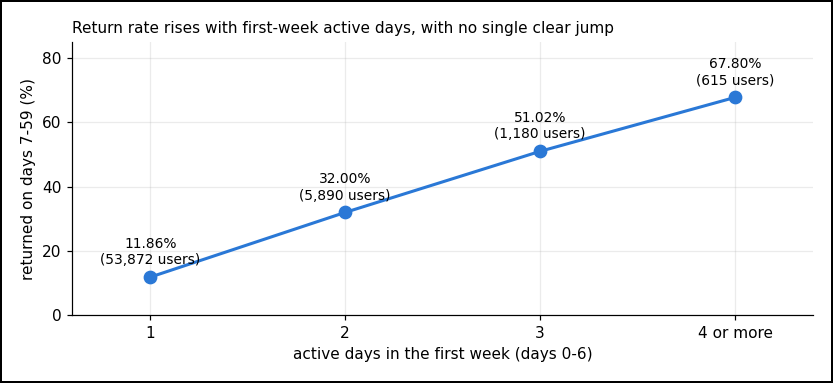

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
x = range(len(by_group))
ax.plot(x, by_group["mean"] * 100, marker="o", markersize=8, linewidth=2, color=BLUE)
for xi, (g, row) in zip(x, by_group.iterrows()):
    ax.text(xi, row["mean"] * 100 + 4, f"{row['mean'] * 100:.2f}%\n({int(row['size']):,} users)", ha="center", fontsize=9)
ax.set_xticks(list(x), by_group.index)
ax.set_xlim(-0.4, len(by_group) - 0.6)
ax.set_xlabel("active days in the first week (days 0-6)")
ax.set_ylabel("returned on days 7-59 (%)")
ax.set_ylim(0, 85)
ax.set_title("Return rate rises with first-week active days, with no single clear jump", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** of 61,557 new users, 53,872 were active only on their first day in week 1, and 11.86% of them came back on days 7–59. With 2 active days, 32.00% came back; with 3, 51.02%; with 4 or more, 67.80%.

**Observation:** up to "4 or more", each step adds between 16.79 and 20.14 points (+20.14, +19.01, +16.79), with no single clear jump; as in the Case Study, any cut-off would be a choice. Past 4 days the groups are small (406 users down to 28) and the steps are uneven (4 → 5 days: 65.02% → 65.38%).

**Two checks on what the pattern means:**
1. **Is it just how *recently* the user was active?** A user active late in week 1 is close to day 7, the start of the outcome window. To give everyone the same quiet gap, each user's outcome window is anchored on their last active day in week 1 (day **i**, from 0 to 6): it starts 7 days after i and lasts 53 days (days i+7 to i+59). Users last active on day 6 need data up to day 65, so this check uses users first seen by 25 December 2019.
2. **Is it about the user rather than the first week?** If keen users are simply more active everywhere, it should show even among users with a single active day: more events on day 0 should go with coming back more often.

In [3]:
last_w1 = c[c["day"] < 7].groupby("user_id")["day"].max().rename("last_day_w1")
u = users.join(last_w1)
u = u[first_day.reindex(u.index) <= "2019-12-25"]   # day i+59 must fall inside the data for i up to 6
cc = c[["user_id", "day"]].join(last_w1, on="user_id")
hit = cc[(cc["day"] >= cc["last_day_w1"] + 7) & (cc["day"] <= cc["last_day_w1"] + 59)]["user_id"].unique()
u["returned_anchored"] = u.index.isin(hit)
r = u.groupby("group").agg(users=("returned", "size"), original=("returned", "mean"), anchored=("returned_anchored", "mean"))
print(f"check 1, outcome window anchored on each user's last active day in week 1 (users first seen by 25 Dec 2019: {len(u):,}):")
show(pd.DataFrame({"active days in week 1": r.index, "users": r["users"].map("{:,}".format).values,
                   "return rate % (days 7-59)": (r["original"] * 100).map("{:.2f}".format).values,
                   "return rate % (days i+7 to i+59)": (r["anchored"] * 100).map("{:.2f}".format).values}))
print()
one_day = users[users["active_days_week1"] == 1].copy()
day0_events = c[c["day"] == 0].set_index("user_id")["events"]
one_day["day0_events"] = day0_events.reindex(one_day.index)
one_day["day0_group"] = one_day["day0_events"].clip(upper=4).map({1: "1", 2: "2", 3: "3", 4: "4 or more"})
r3 = one_day.groupby("day0_group")["returned"].agg(["size", "mean"])
print("check 2, users active only on day 0, by how many events they had that day:")
show(pd.DataFrame({"events on day 0": r3.index, "users": r3["size"].map("{:,}".format).values,
                   "return rate %": (r3["mean"] * 100).map("{:.2f}".format).values}))

check 1, outcome window anchored on each user's last active day in week 1 (users first seen by 25 Dec 2019: 56,689):
active days in week 1   users  return rate % (days 7-59)  return rate % (days i+7 to i+59)
1                      49,453                      11.98                             11.98
2                       5,533                      32.13                             28.66
3                       1,118                      51.25                             42.75
4 or more                 585                      67.86                             52.65

check 2, users active only on day 0, by how many events they had that day:
events on day 0   users  return rate %
1                33,112           8.98
2                 7,765          12.58
3                 3,326          14.55
4 or more         9,669          20.21


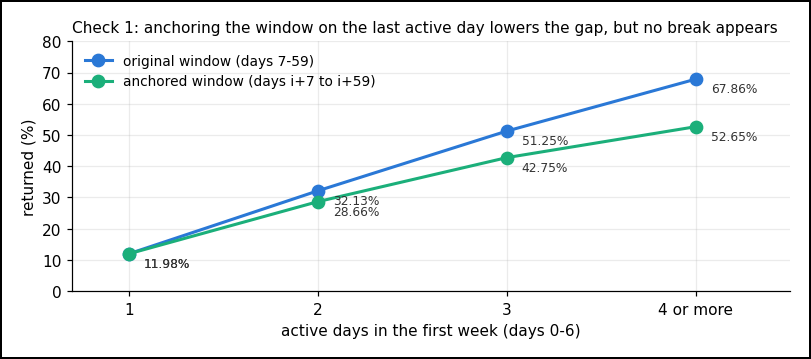

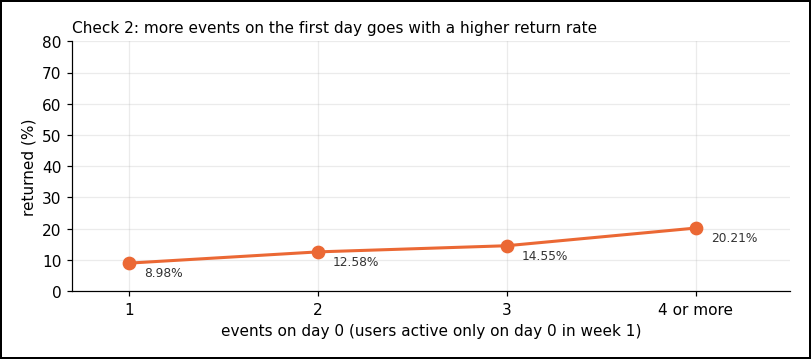

In [4]:
from common import AQUA, ORANGE
def aligned_axes():
    fig, ax = plt.subplots(figsize=(7.5, 3.2))
    fig.subplots_adjust(left=0.1, right=0.97, bottom=0.17, top=0.88)
    return fig, ax

x = range(4)
fig, ax = aligned_axes()
for col, color, label in [("original", BLUE, "original window (days 7-59)"), ("anchored", AQUA, "anchored window (days i+7 to i+59)")]:
    ax.plot(x, r[col] * 100, marker="o", markersize=8, linewidth=2, color=color, label=label)
    for xi, v in zip(x, r[col] * 100):
        ax.text(xi + 0.08, v - 1, f"{v:.2f}%", fontsize=8, va="top", color="#333333")
ax.set_xticks(list(x), r.index); ax.set_xlim(-0.3, 3.5); ax.set_ylim(0, 80)
ax.set_xlabel("active days in the first week (days 0-6)"); ax.set_ylabel("returned (%)")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("Check 1: anchoring the window on the last active day lowers the gap, but no break appears", fontsize=10, loc="left")
plt.show()

fig, ax = aligned_axes()
ax.plot(x, r3["mean"] * 100, marker="o", markersize=8, linewidth=2, color=ORANGE)
for xi, v in zip(x, r3["mean"] * 100):
    ax.text(xi + 0.08, v - 1, f"{v:.2f}%", fontsize=8, va="top", color="#333333")
ax.set_xticks(list(x), r3.index); ax.set_xlim(-0.3, 3.5); ax.set_ylim(0, 80)
ax.set_xlabel("events on day 0 (users active only on day 0 in week 1)"); ax.set_ylabel("returned (%)")
ax.set_title("Check 2: more events on the first day goes with a higher return rate", fontsize=10, loc="left")
plt.show()

**Observation, check 1:** with the anchored window, the rates are 11.98% → 28.66% → 42.75% → 52.65%. The 1-day group doesn't change (its window doesn't move); the others drop. Recency explains part of the gap, but the pattern remains.

**Observation, check 2:** among users active only on day 0, the return rate rises with the number of events that day: 8.98% (1 event), 12.58% (2), 14.55% (3), 20.21% (4 or more). So users already differ before any second active day: on day 0 alone, the return rate ranges from 8.98% to 20.21%, part of the way to the 32.00% of users with 2 active days (same cohort, same window). This suggests the user explains some of the first-week pattern, but not all of it.

**Conclusion:** first-week activity is strongly *associated* with coming back. It is not shown to *cause* it: check 2 points to the user, not the week, as at least part of the explanation. One possible reason is that keen shoppers are both more active early and more likely to return.

## Key takeaways

- **Recap:** an activation metric is chosen, not discovered: the cut-off is usually a choice, in the Case Study (`02_Activation.ipynb`) as well as here.
- **Observation:** on this store, 53,872 of 61,557 new users are active only on their first day in week 1.
- **Observation:** the return rate rises from 11.86% (1 active day) to 67.80% (4 or more), with no single clear jump, and the pattern survives anchoring each user's outcome window on their last active day in week 1.
- **Conclusion:** first-week activity is associated with coming back, not shown to cause it; part of the difference is visible on the very first day.